# Notebook 11 — Intervention Experiments

## Patient Similarity Network + Agent-Based Modelling for Readmission

### Purpose
Compare four intervention policies on the **held-out validation population** using the calibrated ABM from Notebook 09 and the validation network constructed from the frozen Notebook 05 representation.

Policies:

1. **No intervention** — natural simulated trajectory.
2. **Random** — randomly select the fixed intervention budget.
3. **Risk-based** — select patients with the highest baseline predicted readmission risk.
4. **Network-informed** — select patients using a pre-registered combination of clinical risk, validation-network importance, and community risk.

### Methodological safeguards

- The final **test set is not used**.
- All policies use the same validation population.
- All targeted policies receive exactly the same intervention budget.
- The same random seeds and common random outcome draws are used across policies.
- The similarity network is built from the frozen **Notebook 05 validation feature matrix**.
- Observed readmission outcomes are **not used for intervention targeting**.
- Notebook 07 training-network centrality is **not assigned to validation patients**.
- Intervention effectiveness is fixed in this notebook; sensitivity is deferred to Notebook 12.
- Network centrality is a structural targeting variable and is not interpreted as causal.

The project proposal defines Notebook 11 as a fair comparison of no intervention, random, risk-based, and network-informed policies with equal budgets, seeds/replications, and initial populations. fileciteturn16file3L1-L4


In [2]:
# 01. Imports and reproducibility

from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.neighbors import NearestNeighbors
import networkx as nx

warnings.filterwarnings("ignore")

SEED = 42
N_REPLICATIONS = 100

# Frozen experiment parameters
INTERVENTION_BUDGET_FRACTION = 0.10
INTERVENTION_EFFECT = 0.20

# Validation network rule: same primary rule as Notebook 06
VALIDATION_K = 10
VALIDATION_SIMILARITY_METRIC = "cosine"
VALIDATION_NETWORK_RULE = "mutual_knn"

np.random.seed(SEED)
random.seed(SEED)

print("Notebook 11 — Intervention Experiments")
print("Seed:", SEED)
print("Replications:", N_REPLICATIONS)
print("Budget fraction:", INTERVENTION_BUDGET_FRACTION)
print("Intervention effect:", INTERVENTION_EFFECT)
print("Validation network:", VALIDATION_SIMILARITY_METRIC, VALIDATION_NETWORK_RULE, "k=", VALIDATION_K)


Notebook 11 — Intervention Experiments
Seed: 42
Replications: 100
Budget fraction: 0.1
Intervention effect: 0.2
Validation network: cosine mutual_knn k= 10


In [3]:
# 02. Locate project root

def find_project_root():
    here = Path.cwd().resolve()
    candidates = [here, *here.parents]

    for p in candidates:
        if (p / "results").exists() and (p / "notebooks").exists():
            return p

    return here

ROOT = find_project_root()
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"

FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Results directory:", RESULTS)
print("Figures directory:", FIGURES)


Project root: C:\Users\Gayatri\OneDrive\Desktop\sna
Results directory: C:\Users\Gayatri\OneDrive\Desktop\sna\results
Figures directory: C:\Users\Gayatri\OneDrive\Desktop\sna\figures


## 03. Required inputs

Notebook 11 uses the following frozen outputs:

- `04_validation_patient_ids.csv`
- `09_abm_validation_no_intervention.csv`
- `05_X_validation.npz`
- `05_validation_feature_patient_ids.csv`
- optionally the Notebook 10 validation checkpoint/metrics file.

The Notebook 09 validation simulation is expected to contain:

`patient_nbr`, `baseline_risk`, `transition_probability`, `random_draw`, `outcome_state`, `intervention_state`, `time_step`.

Only `patient_nbr`, `baseline_risk`, and `transition_probability` are used for intervention targeting/simulation setup. `outcome_state` is never used to select intervention targets.


In [4]:
# 04. File discovery

def first_existing(names):
    for name in names:
        p = RESULTS / name
        if p.exists():
            return p
    return None

def find_matching(patterns):
    for pattern in patterns:
        matches = sorted(RESULTS.glob(pattern))
        if matches:
            return matches[0]
    return None

VAL_IDS_PATH = first_existing([
    "04_validation_patient_ids.csv",
    "04_validation_ids.csv",
    "04_validation_patients.csv",
]) or find_matching([
    "04*validation*patient*id*.csv",
    "04*validation*id*.csv",
])

VAL_SIM_PATH = first_existing([
    "09_abm_validation_no_intervention.csv",
]) or find_matching([
    "09*validation*no*intervention*.csv",
])

X_VAL_PATH = RESULTS / "05_X_validation.npz"

VAL_FEATURE_IDS_PATH = (
    RESULTS / "05_validation_feature_patient_ids.csv"
)

NOTEBOOK10_CHECKPOINT = first_existing([
    "10_abm_validation_checkpoint.json",
    "10_validation_checkpoint.json",
    "10_abm_validation_metrics.json",
]) or find_matching([
    "10*checkpoint*.json",
    "10*validation*metric*.json",
])

print("Validation IDs:", VAL_IDS_PATH)
print("Notebook 09 validation simulation:", VAL_SIM_PATH)
print("Validation feature matrix:", X_VAL_PATH)
print("Validation feature IDs:", VAL_FEATURE_IDS_PATH)
print("Notebook 10 validation file:", NOTEBOOK10_CHECKPOINT)

assert VAL_IDS_PATH is not None, "STOP: Notebook 04 validation patient-ID file not found."
assert VAL_SIM_PATH is not None, "STOP: Notebook 09 validation simulation not found."
assert X_VAL_PATH.exists(), "STOP: Notebook 05 validation feature matrix not found."
assert VAL_FEATURE_IDS_PATH.exists(), "STOP: Notebook 05 validation feature-ID file not found."


Validation IDs: C:\Users\Gayatri\OneDrive\Desktop\sna\results\04_validation_patient_ids.csv
Notebook 09 validation simulation: C:\Users\Gayatri\OneDrive\Desktop\sna\results\09_abm_validation_no_intervention.csv
Validation feature matrix: C:\Users\Gayatri\OneDrive\Desktop\sna\results\05_X_validation.npz
Validation feature IDs: C:\Users\Gayatri\OneDrive\Desktop\sna\results\05_validation_feature_patient_ids.csv
Notebook 10 validation file: C:\Users\Gayatri\OneDrive\Desktop\sna\results\10_abm_validation_metrics.json


In [5]:
# 05. Load validation inputs

val_ids = pd.read_csv(VAL_IDS_PATH)
val_sim = pd.read_csv(VAL_SIM_PATH)

X_validation = sparse.load_npz(X_VAL_PATH)
val_feature_ids = pd.read_csv(VAL_FEATURE_IDS_PATH)

print("Validation IDs shape:", val_ids.shape)
print("Validation simulation shape:", val_sim.shape)
print("Validation feature matrix shape:", X_validation.shape)
print("Validation feature ID shape:", val_feature_ids.shape)

print("\nValidation simulation columns:")
print(val_sim.columns.tolist())

print("\nValidation feature ID columns:")
print(val_feature_ids.columns.tolist())


Validation IDs shape: (10728, 1)
Validation simulation shape: (10728, 7)
Validation feature matrix shape: (10728, 57)
Validation feature ID shape: (10728, 1)

Validation simulation columns:
['patient_nbr', 'baseline_risk', 'transition_probability', 'random_draw', 'outcome_state', 'intervention_state', 'time_step']

Validation feature ID columns:
['patient_nbr']


In [6]:
# 06. Resolve columns and verify Notebook 09 validation simulation

def resolve_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

VAL_ID_COL = resolve_column(val_ids, ["patient_nbr", "patient_id"])
SIM_ID_COL = resolve_column(val_sim, ["patient_nbr", "patient_id"])

BASELINE_RISK_COL = resolve_column(
    val_sim,
    ["baseline_risk", "risk_probability", "readmission_risk"]
)

TRANSITION_PROB_COL = resolve_column(
    val_sim,
    ["transition_probability", "readmission_probability", "simulated_probability"]
)

assert VAL_ID_COL is not None, "STOP: Validation patient ID column not found."
assert SIM_ID_COL is not None, "STOP: Simulation patient ID column not found."
assert BASELINE_RISK_COL is not None, "STOP: baseline_risk not found in Notebook 09 validation simulation."
assert TRANSITION_PROB_COL is not None, "STOP: transition_probability not found in Notebook 09 validation simulation."

print("Validation ID column:", VAL_ID_COL)
print("Simulation ID column:", SIM_ID_COL)
print("Baseline risk column:", BASELINE_RISK_COL)
print("Transition probability column:", TRANSITION_PROB_COL)

assert "outcome_state" in val_sim.columns, (
    "STOP: Notebook 09 validation simulation does not contain outcome_state. "
    "Check the Notebook 09 output."
)

print("PASS | Notebook 09 validation simulation has expected ABM state")


Validation ID column: patient_nbr
Simulation ID column: patient_nbr
Baseline risk column: baseline_risk
Transition probability column: transition_probability
PASS | Notebook 09 validation simulation has expected ABM state


In [7]:
# 07. Build clean validation ABM population

# Validation patient IDs
population = val_ids[[VAL_ID_COL]].copy()
population = population.rename(columns={VAL_ID_COL: "patient_id"})

# Normalize IDs consistently
population["patient_id"] = (
    population["patient_id"].astype(str).str.strip()
)

# Use Notebook 09 validation simulation as the source of calibrated
# baseline risk and transition probability.
sim_population = val_sim[
    [
        SIM_ID_COL,
        BASELINE_RISK_COL,
        TRANSITION_PROB_COL
    ]
].copy()

sim_population = sim_population.rename(columns={
    SIM_ID_COL: "patient_id",
    BASELINE_RISK_COL: "baseline_risk",
    TRANSITION_PROB_COL: "transition_probability"
})

sim_population["patient_id"] = (
    sim_population["patient_id"].astype(str).str.strip()
)

sim_population["baseline_risk"] = pd.to_numeric(
    sim_population["baseline_risk"],
    errors="coerce"
)

sim_population["transition_probability"] = pd.to_numeric(
    sim_population["transition_probability"],
    errors="coerce"
)

assert sim_population["patient_id"].is_unique
assert sim_population["baseline_risk"].notna().all()
assert sim_population["transition_probability"].notna().all()
assert sim_population["transition_probability"].between(0, 1).all()

population = population.merge(
    sim_population,
    on="patient_id",
    how="left",
    validate="one_to_one"
)

assert len(population) == len(val_ids)
assert population["patient_id"].is_unique
assert population["baseline_risk"].notna().all()
assert population["transition_probability"].notna().all()
assert population["transition_probability"].between(0, 1).all()

print("Validation intervention population:", population.shape)
display(population.head())

print("PASS | validation population constructed")
print("PASS | baseline risk available")
print("PASS | transition probability available")
print("PASS | probabilities bounded")


Validation intervention population: (10728, 3)


,patient_id,baseline_risk,transition_probability
0,1305,0.051906,0.051906
1,4302,0.043067,0.043067
2,8460,0.047854,0.047854
3,12240,0.040706,0.040706
4,13041,0.954883,0.954883


PASS | validation population constructed
PASS | baseline risk available
PASS | transition probability available
PASS | probabilities bounded


In [8]:
# 08. Align frozen Notebook 05 validation features

FEATURE_ID_COL = resolve_column(
    val_feature_ids,
    ["patient_nbr", "patient_id"]
)

assert FEATURE_ID_COL is not None

feature_patient_ids = (
    val_feature_ids[FEATURE_ID_COL]
    .astype(str)
    .str.strip()
    .tolist()
)

assert len(feature_patient_ids) == X_validation.shape[0]
assert len(feature_patient_ids) == len(set(feature_patient_ids))

population_ids = set(population["patient_id"])
feature_ids = set(feature_patient_ids)

assert population_ids == feature_ids, (
    "STOP: Notebook 05 validation feature patients do not "
    "match Notebook 11 validation population."
)

position_map = {
    pid: i
    for i, pid in enumerate(feature_patient_ids)
}

population["_feature_position"] = (
    population["patient_id"].map(position_map)
)

assert population["_feature_position"].notna().all()

population = (
    population
    .sort_values("_feature_position")
    .drop(columns="_feature_position")
    .reset_index(drop=True)
)

assert population["patient_id"].tolist() == feature_patient_ids

print("PASS | validation feature matrix aligned")
print("Feature dimensions:", X_validation.shape)


PASS | validation feature matrix aligned
Feature dimensions: (10728, 57)


## 09. Construct a validation patient-similarity network

Notebook 07's SNA outputs describe the **training network** and therefore cannot be directly attached to the validation patients.

For intervention targeting, this notebook constructs a separate validation clinical/patient similarity network from the already-frozen Notebook 05 validation representation.

Network rule:
- cosine similarity;
- 10 nearest neighbours;
- mutual-kNN;
- edge weight = cosine similarity;
- no observed readmission outcome is used.

This preserves the proposal's requirement that the readmission outcome must not define the similarity network used for intervention discovery. fileciteturn16file0L1-L4


In [9]:
# 10. Build validation mutual-kNN similarity network

nn = NearestNeighbors(
    n_neighbors=VALIDATION_K + 1,
    metric=VALIDATION_SIMILARITY_METRIC,
    algorithm="brute"
)

nn.fit(X_validation)

distances, indices = nn.kneighbors(X_validation)

neighbor_indices = indices[:, 1:]
neighbor_distances = distances[:, 1:]

neighbor_similarity = np.clip(
    1.0 - neighbor_distances,
    -1.0,
    1.0
)

G_val = nx.Graph()

for pid in feature_patient_ids:
    G_val.add_node(pid)

directed_neighbors = [
    set(row)
    for row in neighbor_indices
]

for i in range(len(feature_patient_ids)):
    pid_i = feature_patient_ids[i]

    for pos, j in enumerate(neighbor_indices[i]):
        if i not in directed_neighbors[j]:
            continue

        pid_j = feature_patient_ids[j]

        if pid_i == pid_j:
            continue

        weight = float(neighbor_similarity[i, pos])

        if weight <= 0:
            continue

        if G_val.has_edge(pid_i, pid_j):
            G_val[pid_i][pid_j]["weight"] = max(
                G_val[pid_i][pid_j]["weight"],
                weight
            )
        else:
            G_val.add_edge(
                pid_i,
                pid_j,
                weight=weight
            )

print("Validation network nodes:", G_val.number_of_nodes())
print("Validation network edges:", G_val.number_of_edges())
print("Validation network density:", nx.density(G_val))


Validation network nodes: 10728
Validation network edges: 30245
Validation network density: 0.0005256377396113857


In [10]:
# 11. Validation network SNA and community detection

assert G_val.number_of_nodes() == len(population)
assert nx.number_of_selfloops(G_val) == 0

assert all(
    data["weight"] > 0
    for _, _, data in G_val.edges(data=True)
)

assert set(G_val.nodes()) == set(feature_patient_ids)

degree = dict(G_val.degree())
weighted_degree = dict(G_val.degree(weight="weight"))

population["validation_degree"] = (
    population["patient_id"].map(degree).fillna(0)
)

population["validation_weighted_degree"] = (
    population["patient_id"].map(weighted_degree).fillna(0)
)

# Weighted Louvain community detection.
# For isolated nodes, networkx returns singleton communities.
communities = nx.community.louvain_communities(
    G_val,
    weight="weight",
    seed=SEED
)

community_map = {}

for community_id, members in enumerate(communities):
    for pid in members:
        community_map[str(pid)] = community_id

population["community"] = (
    population["patient_id"].map(community_map)
)

assert population["community"].notna().all()

print("Connected components:", nx.number_connected_components(G_val))
print("Isolated nodes:", sum(d == 0 for _, d in G_val.degree()))
print("Communities:", len(communities))
print("Largest community:", max(len(c) for c in communities))

print("PASS | validation network integrity")
print("PASS | weighted degree calculated")
print("PASS | validation communities calculated")


Connected components: 291
Isolated nodes: 248
Communities: 316
Largest community: 709
PASS | validation network integrity
PASS | weighted degree calculated
PASS | validation communities calculated


In [11]:
# 12. Build the pre-registered network-informed targeting score

# Community mean baseline risk is based ONLY on predicted risk,
# never on observed validation outcomes.

community_mean_risk = (
    population
    .groupby("community", observed=True)["baseline_risk"]
    .mean()
    .rename("community_mean_risk")
)

population = population.join(
    community_mean_risk,
    on="community"
)

assert population["community_mean_risk"].notna().all()

population["risk_percentile"] = (
    population["baseline_risk"].rank(
        method="average",
        pct=True
    )
)

population["network_percentile"] = (
    population["validation_weighted_degree"].rank(
        method="average",
        pct=True
    )
)

population["community_risk_percentile"] = (
    population["community_mean_risk"].rank(
        method="average",
        pct=True
    )
)

# Pre-registered score:
# 70% clinical risk + 20% network importance + 10% community risk
population["network_informed_score"] = (
    0.70 * population["risk_percentile"]
    + 0.20 * population["network_percentile"]
    + 0.10 * population["community_risk_percentile"]
)

assert population["network_informed_score"].notna().all()
assert np.isfinite(population["network_informed_score"]).all()
assert population["network_informed_score"].between(0, 1).all()

print("PASS | network-informed score created")
display(
    population[
        [
            "patient_id",
            "baseline_risk",
            "validation_weighted_degree",
            "community",
            "community_mean_risk",
            "network_informed_score"
        ]
    ].head(10)
)


PASS | network-informed score created


,patient_id,baseline_risk,validation_weighted_degree,community,community_mean_risk,network_informed_score
0,1305,0.051906,8.114066,66,0.042543,0.601165
1,4302,0.043067,7.597271,208,0.037439,0.457844
2,8460,0.047854,5.477254,238,0.033088,0.467016
3,12240,0.040706,4.723335,133,0.043410,0.378407
4,13041,0.954883,7.682213,157,0.641634,0.952321
5,16623,0.028299,3.567122,183,0.044736,0.175051
6,20232,0.213049,6.883730,0,0.240648,0.823001
7,20772,0.048410,9.531741,196,0.037691,0.573765
8,20997,0.073719,2.263069,287,0.094082,0.607429
9,25434,0.065821,4.344172,228,0.060231,0.626613


In [12]:
# 13. Freeze intervention budget

N_PATIENTS = len(population)

INTERVENTION_COUNT = int(
    round(
        N_PATIENTS
        * INTERVENTION_BUDGET_FRACTION
    )
)

assert INTERVENTION_COUNT > 0
assert INTERVENTION_COUNT <= N_PATIENTS

POLICIES = [
    "no_intervention",
    "random",
    "risk_based",
    "network_informed"
]

print("Validation patients:", N_PATIENTS)
print("Budget fraction:", INTERVENTION_BUDGET_FRACTION)
print("Targeted intervention count:", INTERVENTION_COUNT)
print("Policies:", POLICIES)

assert N_PATIENTS == 10728
assert INTERVENTION_COUNT == 1073

print("PASS | fixed intervention budget")


Validation patients: 10728
Budget fraction: 0.1
Targeted intervention count: 1073
Policies: ['no_intervention', 'random', 'risk_based', 'network_informed']
PASS | fixed intervention budget


In [13]:
# 14. Freeze deterministic risk and network target sets

risk_order = (
    population
    .sort_values(
        ["baseline_risk", "patient_id"],
        ascending=[False, True]
    )
    .head(INTERVENTION_COUNT)["patient_id"]
    .tolist()
)

network_order = (
    population
    .sort_values(
        ["network_informed_score", "patient_id"],
        ascending=[False, True]
    )
    .head(INTERVENTION_COUNT)["patient_id"]
    .tolist()
)

risk_set = set(risk_order)
network_set = set(network_order)

assert len(risk_set) == INTERVENTION_COUNT
assert len(network_set) == INTERVENTION_COUNT

risk_selected = population[
    population["patient_id"].isin(risk_set)
]

network_selected = population[
    population["patient_id"].isin(network_set)
]

target_selection_audit = pd.DataFrame({
    "policy": [
        "risk_based",
        "network_informed"
    ],
    "intervention_count": [
        len(risk_set),
        len(network_set)
    ],
    "mean_baseline_risk": [
        risk_selected["baseline_risk"].mean(),
        network_selected["baseline_risk"].mean()
    ],
    "mean_network_importance": [
        risk_selected["validation_weighted_degree"].mean(),
        network_selected["validation_weighted_degree"].mean()
    ],
    "mean_network_informed_score": [
        risk_selected["network_informed_score"].mean(),
        network_selected["network_informed_score"].mean()
    ]
})

display(target_selection_audit)

print("PASS | risk target set frozen")
print("PASS | network-informed target set frozen")


,policy,intervention_count,mean_baseline_risk,mean_network_importance,mean_network_informed_score
0,risk_based,1073,0.632192,4.475131,0.841855
1,network_informed,1073,0.550149,6.146062,0.862160


PASS | risk target set frozen
PASS | network-informed target set frozen


In [14]:
# 15. Generate common random numbers

# Each replication gets:
#   - one random target set;
#   - one common outcome-draw vector.
#
# The same outcome draws are reused across all four policies.

random_target_sets = {}
common_outcome_draws = {}

all_patient_ids = population["patient_id"].to_numpy()

for rep in range(N_REPLICATIONS):

    rng = np.random.default_rng(
        SEED + rep
    )

    random_target_sets[rep] = set(
        rng.choice(
            all_patient_ids,
            size=INTERVENTION_COUNT,
            replace=False
        ).tolist()
    )

    common_outcome_draws[rep] = rng.random(
        N_PATIENTS
    )

assert all(
    len(random_target_sets[r])
    == INTERVENTION_COUNT
    for r in range(N_REPLICATIONS)
)

assert all(
    len(common_outcome_draws[r])
    == N_PATIENTS
    for r in range(N_REPLICATIONS)
)

print("PASS | random target sets reproducible")
print("PASS | common random outcome draws generated")


PASS | random target sets reproducible
PASS | common random outcome draws generated


## 16. Intervention transition rule

The calibrated Notebook 09 transition probability is the no-intervention probability.

For an intervention-targeted patient:

**P(readmission | intervention) = P(readmission | no intervention) × (1 − intervention effect)**

The fixed intervention effect for Notebook 11 is **20%**.

This is a simulation assumption, not an estimated causal treatment effect. Notebook 12 will test different intervention-effect assumptions. The proposal explicitly requires sensitivity analysis for intervention effectiveness. fileciteturn16file1L1-L4


In [15]:
# 17. Simulation function

def get_policy_targets(policy, replication):

    if policy == "no_intervention":
        return set()

    if policy == "random":
        return random_target_sets[replication]

    if policy == "risk_based":
        return risk_set

    if policy == "network_informed":
        return network_set

    raise ValueError(
        f"Unknown policy: {policy}"
    )


def simulate_policy(policy, replication):

    targets = get_policy_targets(
        policy,
        replication
    )

    base_probability = (
        population[
            "transition_probability"
        ]
        .to_numpy(dtype=float)
    )

    intervention_mask = (
        population[
            "patient_id"
        ]
        .isin(targets)
        .to_numpy()
    )

    probability = base_probability.copy()

    if policy != "no_intervention":

        probability[
            intervention_mask
        ] = (
            probability[
                intervention_mask
            ]
            * (1.0 - INTERVENTION_EFFECT)
        )

    probability = np.clip(
        probability,
        0.0,
        1.0
    )

    draws = common_outcome_draws[
        replication
    ]

    outcomes = (
        draws < probability
    ).astype(int)

    return {
        "policy": policy,
        "replication": replication,
        "n_patients": N_PATIENTS,
        "intervention_count": int(
            intervention_mask.sum()
        ),
        "readmissions": int(
            outcomes.sum()
        ),
        "readmission_rate": float(
            outcomes.mean()
        ),
        "mean_transition_probability": float(
            probability.mean()
        )
    }


# Hand-check the function on one replication.
for policy in POLICIES:
    result = simulate_policy(
        policy,
        0
    )
    print(
        policy,
        "->",
        result["readmissions"],
        "readmissions"
    )


no_intervention -> 1328 readmissions
random -> 1302 readmissions
risk_based -> 1181 readmissions
network_informed -> 1200 readmissions


In [16]:
# 18. Run all policy replications

records = []

for rep in range(N_REPLICATIONS):

    for policy in POLICIES:

        records.append(
            simulate_policy(
                policy,
                rep
            )
        )

replication_results = pd.DataFrame(
    records
)

assert len(replication_results) == (
    N_REPLICATIONS * len(POLICIES)
)

# Add the paired no-intervention result
baseline_rep = (
    replication_results[
        replication_results[
            "policy"
        ] == "no_intervention"
    ][
        [
            "replication",
            "readmissions",
            "readmission_rate"
        ]
    ]
    .rename(columns={
        "readmissions":
            "no_intervention_readmissions",
        "readmission_rate":
            "no_intervention_rate"
    })
)

replication_results = (
    replication_results
    .merge(
        baseline_rep,
        on="replication",
        how="left",
        validate="many_to_one"
    )
)

replication_results[
    "prevented_vs_no_intervention"
] = (
    replication_results[
        "no_intervention_readmissions"
    ]
    - replication_results[
        "readmissions"
    ]
)

replication_results[
    "absolute_reduction"
] = (
    replication_results[
        "no_intervention_rate"
    ]
    - replication_results[
        "readmission_rate"
    ]
)

replication_results[
    "relative_reduction"
] = (
    replication_results[
        "absolute_reduction"
    ]
    / replication_results[
        "no_intervention_rate"
    ]
)

replication_results[
    "intervention_efficiency"
] = np.nan

mask = (
    replication_results[
        "intervention_count"
    ] > 0
)

replication_results.loc[
    mask,
    "intervention_efficiency"
] = (
    replication_results.loc[
        mask,
        "prevented_vs_no_intervention"
    ]
    / replication_results.loc[
        mask,
        "intervention_count"
    ]
)

display(
    replication_results.head(12)
)

print(
    "Total policy-replication rows:",
    len(replication_results)
)


,policy,replication,n_patients,intervention_count,readmissions,readmission_rate,mean_transition_probability,no_intervention_readmissions,no_intervention_rate,prevented_vs_no_intervention,absolute_reduction,relative_reduction,intervention_efficiency
0,no_intervention,0,10728,0,1328,0.123788,0.123423,1328,0.123788,0,0.000000,0.000000,NaN
1,random,0,10728,1073,1302,0.121365,0.120961,1328,0.123788,26,0.002424,0.019578,0.024231
2,risk_based,0,10728,1073,1181,0.110086,0.110777,1328,0.123788,147,0.013702,0.110693,0.136999
3,network_informed,0,10728,1073,1200,0.111857,0.112418,1328,0.123788,128,0.011931,0.096386,0.119292
4,no_intervention,1,10728,0,1348,0.125652,0.123423,1348,0.125652,0,0.000000,0.000000,NaN
5,random,1,10728,1073,1323,0.123322,0.121125,1348,0.125652,25,0.002330,0.018546,0.023299
6,risk_based,1,10728,1073,1196,0.111484,0.110777,1348,0.125652,152,0.014169,0.112760,0.141659
7,network_informed,1,10728,1073,1218,0.113535,0.112418,1348,0.125652,130,0.012118,0.096439,0.121156
8,no_intervention,2,10728,0,1313,0.122390,0.123423,1313,0.122390,0,0.000000,0.000000,NaN
9,random,2,10728,1073,1281,0.119407,0.120996,1313,0.122390,32,0.002983,0.024372,0.029823


Total policy-replication rows: 400


In [17]:
# 19. Equal-resource and reproducibility checks

resource_checks = {

    "same_population_size":
        replication_results[
            "n_patients"
        ].nunique() == 1,

    "same_replication_count":
        replication_results.groupby(
            "policy"
        )["replication"].nunique().eq(
            N_REPLICATIONS
        ).all(),

    "same_target_budget":
        replication_results[
            replication_results["policy"]
            != "no_intervention"
        ]["intervention_count"].nunique() == 1,

    "no_intervention_zero_targets":
        replication_results[
            replication_results["policy"]
            == "no_intervention"
        ]["intervention_count"].eq(0).all(),

    "targeted_policies_use_fixed_budget":
        replication_results[
            replication_results["policy"]
            != "no_intervention"
        ]["intervention_count"].eq(
            INTERVENTION_COUNT
        ).all(),

    "probabilities_bounded":
        replication_results[
            "mean_transition_probability"
        ].between(0, 1).all()
}

for name, passed in resource_checks.items():
    print(
        "PASS |" if passed else "FAIL |",
        name
    )

assert all(resource_checks.values()), (
    "STOP: Equal-resource checkpoint failed."
)


# Reproducibility test
rep_a = pd.DataFrame([
    simulate_policy(policy, 17)
    for policy in POLICIES
])

rep_b = pd.DataFrame([
    simulate_policy(policy, 17)
    for policy in POLICIES
])

assert rep_a.equals(rep_b)

print("PASS | reproducibility test")


PASS | same_population_size
PASS | same_replication_count
PASS | same_target_budget
PASS | no_intervention_zero_targets
PASS | targeted_policies_use_fixed_budget
PASS | probabilities_bounded
PASS | reproducibility test


In [18]:
# 20. Policy summary and 95% simulation uncertainty intervals

def summarize_policy(group):

    n = len(group)

    mean_rate = group[
        "readmission_rate"
    ].mean()

    sd_rate = group[
        "readmission_rate"
    ].std(ddof=1)

    se_rate = sd_rate / np.sqrt(n)

    mean_prevented = group[
        "prevented_vs_no_intervention"
    ].mean()

    mean_absolute = group[
        "absolute_reduction"
    ].mean()

    mean_relative = group[
        "relative_reduction"
    ].mean()

    mean_efficiency = group[
        "intervention_efficiency"
    ].mean()

    return pd.Series({

        "replications": n,

        "patients_per_replication":
            group[
                "n_patients"
            ].iloc[0],

        "intervention_count":
            group[
                "intervention_count"
            ].iloc[0],

        "mean_readmission_rate":
            mean_rate,

        "sd_readmission_rate":
            sd_rate,

        "ci95_low":
            mean_rate - 1.96 * se_rate,

        "ci95_high":
            mean_rate + 1.96 * se_rate,

        "mean_prevented_vs_no_intervention":
            mean_prevented,

        "mean_absolute_reduction":
            mean_absolute,

        "mean_relative_reduction":
            mean_relative,

        "mean_intervention_efficiency":
            mean_efficiency
    })


policy_summary = (
    replication_results
    .groupby(
        "policy",
        sort=False
    )
    .apply(
        summarize_policy
    )
    .reset_index()
)

display(policy_summary)


,policy,replications,patients_per_replication,intervention_count,mean_readmission_rate,sd_readmission_rate,ci95_low,ci95_high,mean_prevented_vs_no_intervention,mean_absolute_reduction,mean_relative_reduction,mean_intervention_efficiency
0,no_intervention,100.0,10728.0,0.0,0.123241,0.002561,0.122739,0.123743,0.00,0.000000,0.000000,NaN
1,random,100.0,10728.0,1073.0,0.120807,0.002580,0.120302,0.121313,26.11,0.002434,0.019753,0.024334
2,risk_based,100.0,10728.0,1073.0,0.110539,0.002549,0.110039,0.111038,136.27,0.012702,0.103080,0.126999
3,network_informed,100.0,10728.0,1073.0,0.112145,0.002574,0.111640,0.112649,119.04,0.011096,0.090053,0.110941


In [19]:
# 21. Paired comparisons against no intervention

paired = replication_results[
    replication_results["policy"]
    != "no_intervention"
].copy()

paired_summary = (
    paired
    .groupby("policy")
    .agg(
        mean_rate_difference=(
            "absolute_reduction",
            lambda x: -x.mean()
        ),
        sd_rate_difference=(
            "absolute_reduction",
            "std"
        ),
        mean_prevented=(
            "prevented_vs_no_intervention",
            "mean"
        ),
        sd_prevented=(
            "prevented_vs_no_intervention",
            "std"
        ),
        mean_efficiency=(
            "intervention_efficiency",
            "mean"
        )
    )
    .reset_index()
)

display(paired_summary)


,policy,mean_rate_difference,sd_rate_difference,mean_prevented,sd_prevented,mean_efficiency
0,network_informed,-0.011096,0.000871,119.04,9.339738,0.110941
1,random,-0.002434,0.000474,26.11,5.084925,0.024334
2,risk_based,-0.012702,0.000980,136.27,10.512960,0.126999


In [20]:
# 22. Save all intervention outputs

replication_results.to_csv(
    RESULTS /
    "11_intervention_replication_results.csv",
    index=False
)

policy_summary.to_csv(
    RESULTS /
    "11_intervention_policy_summary.csv",
    index=False
)

paired_summary.to_csv(
    RESULTS /
    "11_paired_policy_comparisons.csv",
    index=False
)

target_selection_audit.to_csv(
    RESULTS /
    "11_target_selection_audit.csv",
    index=False
)

validation_nodes = population[
    [
        "patient_id",
        "baseline_risk",
        "transition_probability",
        "validation_degree",
        "validation_weighted_degree",
        "community",
        "community_mean_risk",
        "risk_percentile",
        "network_percentile",
        "community_risk_percentile",
        "network_informed_score"
    ]
].copy()

validation_nodes.to_csv(
    RESULTS /
    "11_validation_network_nodes.csv",
    index=False
)

validation_edges = pd.DataFrame([
    {
        "patient_nbr_1": u,
        "patient_nbr_2": v,
        "similarity_weight": data["weight"]
    }
    for u, v, data in G_val.edges(data=True)
])

validation_edges.to_csv(
    RESULTS /
    "11_validation_similarity_edges_k10.csv",
    index=False
)

config = {
    "notebook": "11_intervention_experiments",
    "seed": SEED,
    "replications": N_REPLICATIONS,
    "validation_population_only": True,
    "test_used": False,
    "validation_patients": N_PATIENTS,
    "intervention_budget_fraction": INTERVENTION_BUDGET_FRACTION,
    "intervention_count": INTERVENTION_COUNT,
    "intervention_effect": INTERVENTION_EFFECT,
    "validation_network": {
        "metric": VALIDATION_SIMILARITY_METRIC,
        "rule": VALIDATION_NETWORK_RULE,
        "k": VALIDATION_K,
        "nodes": int(G_val.number_of_nodes()),
        "edges": int(G_val.number_of_edges())
    },
    "network_informed_score": {
        "risk_weight": 0.70,
        "network_weight": 0.20,
        "community_risk_weight": 0.10
    },
    "policies": POLICIES,
    "common_random_numbers": True,
    "observed_outcome_used_for_targeting": False
}

with open(
    RESULTS /
    "11_intervention_config.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        config,
        f,
        indent=2
    )

print("PASS | intervention outputs saved")


PASS | intervention outputs saved


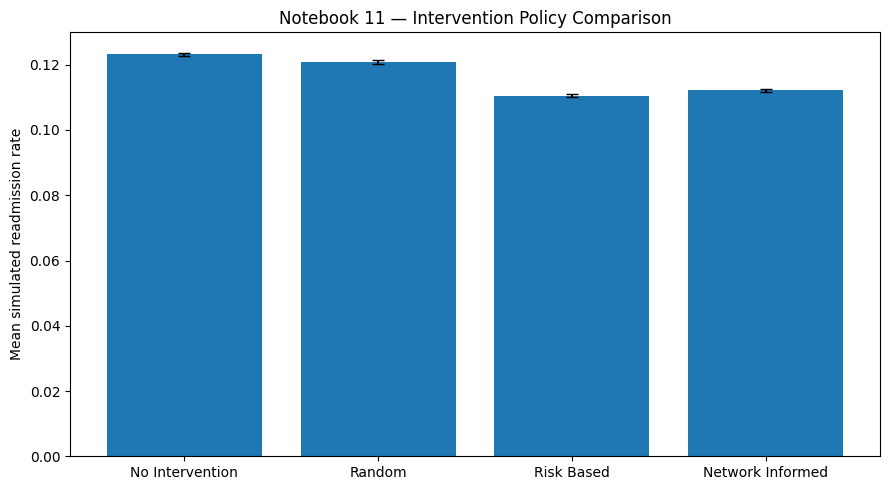

Saved: C:\Users\Gayatri\OneDrive\Desktop\sna\figures\11_intervention_policy_comparison.png


In [21]:
# 23. Plot simulated readmission rates

plot_df = policy_summary.copy()

x = np.arange(len(plot_df))
means = plot_df[
    "mean_readmission_rate"
].to_numpy()

lower = plot_df[
    "ci95_low"
].to_numpy()

upper = plot_df[
    "ci95_high"
].to_numpy()

yerr = np.vstack([
    means - lower,
    upper - means
])

plt.figure(figsize=(9, 5))

plt.bar(
    x,
    means,
    yerr=yerr,
    capsize=4
)

plt.xticks(
    x,
    plot_df[
        "policy"
    ].str.replace(
        "_",
        " "
    ).str.title()
)

plt.ylabel(
    "Mean simulated readmission rate"
)

plt.title(
    "Notebook 11 — Intervention Policy Comparison"
)

plt.tight_layout()

POLICY_FIG = (
    FIGURES /
    "11_intervention_policy_comparison.png"
)

plt.savefig(
    POLICY_FIG,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    POLICY_FIG
)


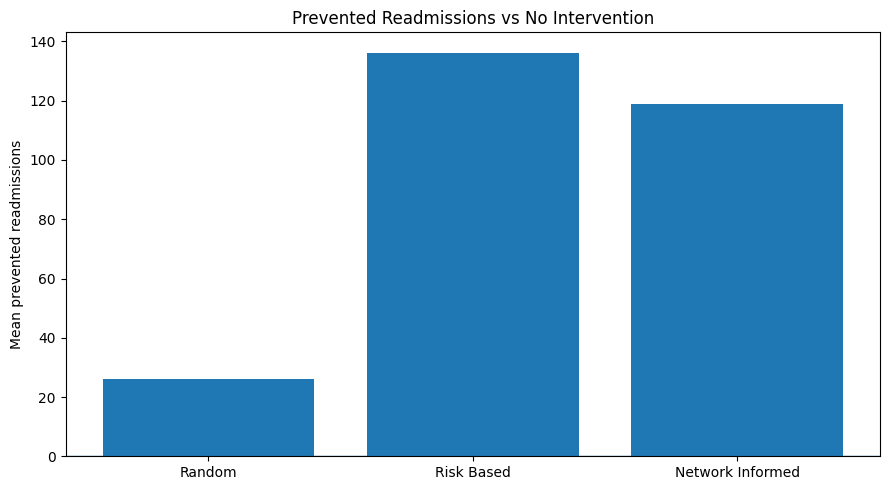

Saved: C:\Users\Gayatri\OneDrive\Desktop\sna\figures\11_prevented_readmissions.png


In [22]:
# 24. Plot prevented readmissions

targeted = policy_summary[
    policy_summary["policy"]
    != "no_intervention"
].copy()

x = np.arange(len(targeted))

values = targeted[
    "mean_prevented_vs_no_intervention"
].to_numpy()

plt.figure(figsize=(9, 5))

plt.bar(
    x,
    values
)

plt.axhline(
    0,
    linewidth=1
)

plt.xticks(
    x,
    targeted[
        "policy"
    ].str.replace(
        "_",
        " "
    ).str.title()
)

plt.ylabel(
    "Mean prevented readmissions"
)

plt.title(
    "Prevented Readmissions vs No Intervention"
)

plt.tight_layout()

PREVENTED_FIG = (
    FIGURES /
    "11_prevented_readmissions.png"
)

plt.savefig(
    PREVENTED_FIG,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    PREVENTED_FIG
)


In [23]:
# 25. Final checkpoint

final_checks = {

    "validation_population_only":
        N_PATIENTS == 10728,

    "test_not_used":
        True,

    "four_policies_present":
        set(POLICIES) == {
            "no_intervention",
            "random",
            "risk_based",
            "network_informed"
        },

    "same_population":
        resource_checks[
            "same_population_size"
        ],

    "same_replication_count":
        resource_checks[
            "same_replication_count"
        ],

    "same_intervention_budget":
        resource_checks[
            "same_target_budget"
        ],

    "no_intervention_zero_budget":
        resource_checks[
            "no_intervention_zero_targets"
        ],

    "targeted_policies_fixed_budget":
        resource_checks[
            "targeted_policies_use_fixed_budget"
        ],

    "probabilities_bounded":
        resource_checks[
            "probabilities_bounded"
        ],

    "reproducible":
        rep_a.equals(rep_b),

    "validation_network_complete":
        G_val.number_of_nodes() == 10728,

    "network_has_edges":
        G_val.number_of_edges() > 0,

    "network_score_available":
        population[
            "network_informed_score"
        ].notna().all(),

    "network_score_bounded":
        population[
            "network_informed_score"
        ].between(0, 1).all(),

    "observed_outcome_not_used":
        True,

    "replication_results_saved":
        (
            RESULTS /
            "11_intervention_replication_results.csv"
        ).exists(),

    "policy_summary_saved":
        (
            RESULTS /
            "11_intervention_policy_summary.csv"
        ).exists(),

    "paired_results_saved":
        (
            RESULTS /
            "11_paired_policy_comparisons.csv"
        ).exists(),

    "target_selection_saved":
        (
            RESULTS /
            "11_target_selection_audit.csv"
        ).exists(),

    "config_saved":
        (
            RESULTS /
            "11_intervention_config.json"
        ).exists(),

    "validation_network_saved":
        (
            RESULTS /
            "11_validation_similarity_edges_k10.csv"
        ).exists(),

    "policy_figure_saved":
        POLICY_FIG.exists(),

    "prevented_figure_saved":
        PREVENTED_FIG.exists()
}


print("=" * 75)
print("NOTEBOOK 11 — FINAL CHECKPOINT")
print("=" * 75)

for name, passed in final_checks.items():
    print(
        "PASS |" if passed else "FAIL |",
        name
    )

if all(final_checks.values()):

    print("OVERALL RESULT: PASS")
    print(
        "Notebook 11 intervention experiments are ready "
        "for manual review and Notebook 12."
    )

else:

    print("OVERALL RESULT: STOP")

    failed = [
        name
        for name, passed in final_checks.items()
        if not passed
    ]

    print("Failed checks:")
    for name in failed:
        print(" -", name)

    raise AssertionError(
        "Notebook 11 checkpoint failed."
    )


NOTEBOOK 11 — FINAL CHECKPOINT
PASS | validation_population_only
PASS | test_not_used
PASS | four_policies_present
PASS | same_population
PASS | same_replication_count
PASS | same_intervention_budget
PASS | no_intervention_zero_budget
PASS | targeted_policies_fixed_budget
PASS | probabilities_bounded
PASS | reproducible
PASS | validation_network_complete
PASS | network_has_edges
PASS | network_score_available
PASS | network_score_bounded
PASS | observed_outcome_not_used
PASS | replication_results_saved
PASS | policy_summary_saved
PASS | paired_results_saved
PASS | target_selection_saved
PASS | config_saved
PASS | validation_network_saved
PASS | policy_figure_saved
PASS | prevented_figure_saved
OVERALL RESULT: PASS
Notebook 11 intervention experiments are ready for manual review and Notebook 12.
